### Monopólios Esportivos

**​A Pergunta:** Quais esportes são dominados por um único país?

​A Comparação: Analisar a porcentagem de medalhas de ouro ganhas por um único país em modalidades específicas.
​Ex: Tênis de Mesa (China), Basquete Masculino (EUA), Corridas de Longa Distância (Quênia/Etiópia), Tiro com Arco (Coreia do Sul).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import scipy.stats as stats

In [2]:
df_atleta = pd.read_csv('athlete_events_arrumado.csv', encoding='utf-8')
df_atleta['Medal'] = df_atleta['Medal'].fillna('0')
display(df_atleta.head())



,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,0
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,0
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,0
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,8,"Cornelia ""Cor"" Aalten (-Strannood)",F,18.0,168.0,NaN,Netherlands,NED,1932 Summer,1932,Summer,Los Angeles,Athletics,Athletics Women's 100 metres,0


In [3]:
df_medalhas = df_atleta.groupby(['NOC', 'Sport'])['Medal'].value_counts().unstack(fill_value=0)

df_total = df_atleta.groupby(['NOC', 'Sport']).size().reset_index(name='Total_Atletas')

df_simples = pd.merge(df_total, df_medalhas, on=['NOC', 'Sport'])

display(df_simples.head())
display(df_simples.head())

,NOC,Sport,Total_Atletas,0,Bronze,Gold,Silver
0,AFG,Athletics,22,22,0,0,0
1,AFG,Boxing,5,5,0,0,0
2,AFG,Football,11,11,0,0,0
3,AFG,Hockey,39,39,0,0,0
4,AFG,Judo,3,3,0,0,0


,NOC,Sport,Total_Atletas,0,Bronze,Gold,Silver
0,AFG,Athletics,22,22,0,0,0
1,AFG,Boxing,5,5,0,0,0
2,AFG,Football,11,11,0,0,0
3,AFG,Hockey,39,39,0,0,0
4,AFG,Judo,3,3,0,0,0


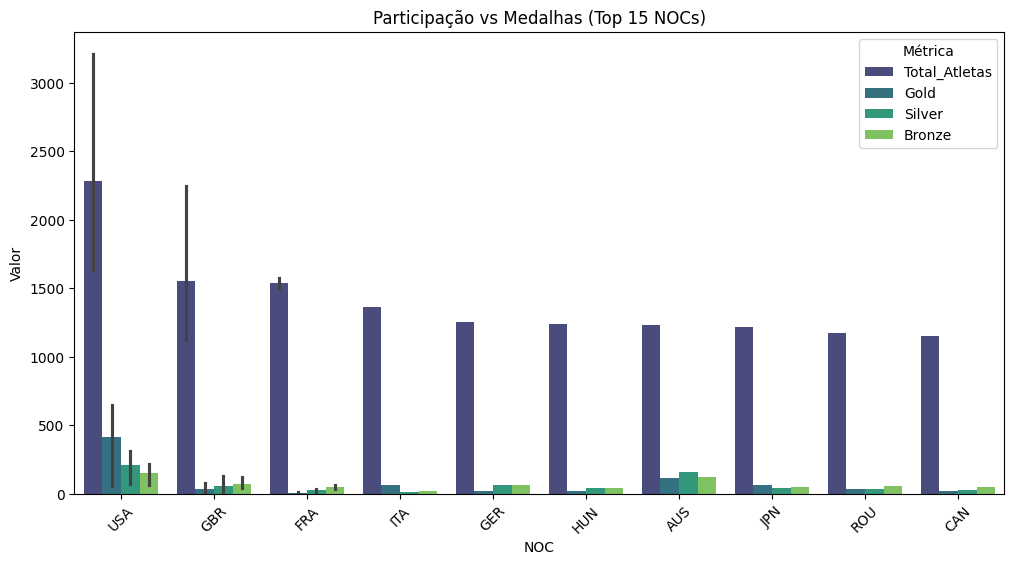

In [ ]:
# Pega os 15 maiores em participação
df_top = df_simples.nlargest(15, 'Total_Atletas')

df_plot = df_top.melt(id_vars=['NOC', 'Sport'], 
                      value_vars=['Total_Atletas', 'Gold', 'Silver', 'Bronze'],
                      var_name='Métrica', 
                      value_name='Valor')

plt.figure(figsize=(12, 6))
sns.barplot(data=df_plot, x='NOC', y='Valor', hue='Métrica', palette='viridis') 
plt.xticks(rotation=45)
plt.title('Participação vs Medalhas (Top 15 NOCs)')
plt.show()

para cada pais analisa os esportes que mais se destacam, e quais esportes tem mais medalhas, e quais esportes tem mais atletas, e quais esportes tem mais medalhas por atleta, e quais esportes tem mais medalhas por atleta por pais, e quais esportes tem mais medalhas por atleta por pais por ano, e quais esportes tem mais medalhas por atleta por pais por ano por genero, e quais esportes tem mais medalhas por atleta por pais por ano por genero por tipo de medalha

In [5]:
# 1. Criar uma coluna com o Total de Medalhas Reais (Ouro + Prata + Bronze)
df_simples['Total_Medalhas'] = df_simples['Gold'] + df_simples['Silver'] + df_simples['Bronze']

# 2. Encontrar o esporte com mais medalhas para cada NOC
# Usamos o idxmax para pegar o índice da linha com o maior valor de medalhas por grupo
idx = df_simples.groupby('NOC')['Total_Medalhas'].idxmax()
df_destaque = df_simples.loc[idx, ['NOC', 'Sport', 'Total_Medalhas', 'Total_Atletas']]

# 3. Calcular a 'Taxa de Sucesso' desse esporte específico
df_destaque['Eficiencia_%'] = (df_destaque['Total_Medalhas'] / df_destaque['Total_Atletas'] * 100).round(2)

# Ordenar pelos países com mais medalhas no seu esporte principal
display(df_destaque.sort_values(by='Total_Medalhas', ascending=False).head(20))

,NOC,Sport,Total_Medalhas,Total_Atletas,Eficiencia_%
3134,USA,Athletics,1080,3211,33.63
169,AUS,Swimming,401,1235,32.47
1590,ITA,Fencing,359,736,48.78
1120,GBR,Athletics,338,2244,15.06
1045,FRA,Fencing,310,982,31.57
3096,URS,Gymnastics,288,797,36.14
2136,NED,Hockey,255,418,61.00
1390,HUN,Fencing,236,628,37.58
1231,GER,Rowing,236,526,44.87
509,CAN,Rowing,203,559,36.31


C:\Users\maria\AppData\Local\Temp\ipykernel_18940\2845203218.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_esportes_top, x='Total_Medalhas', y='Sport', palette='viridis')


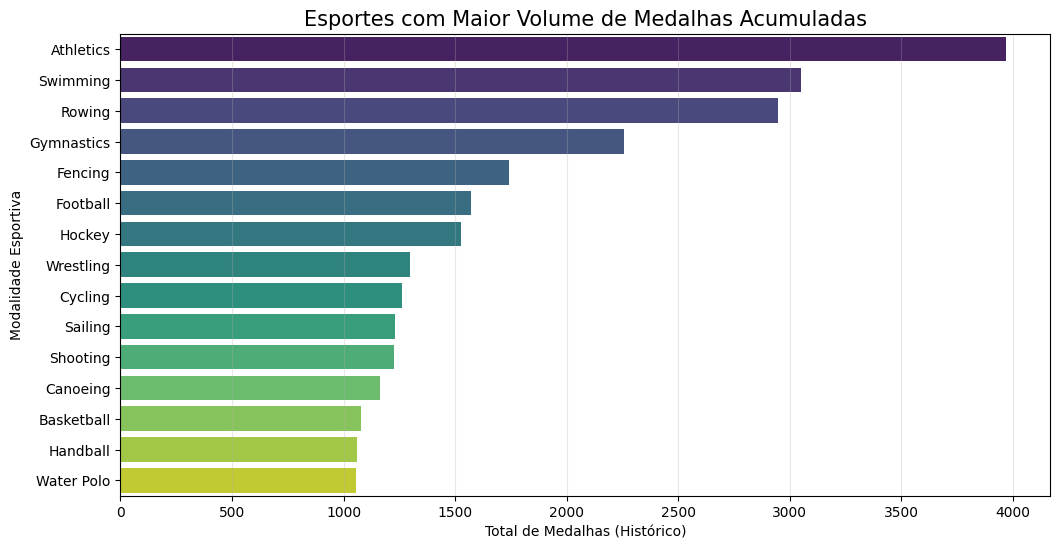

In [6]:
# Agrupar por esporte para ver quais são os mais "generosos" em medalhas
df_esportes_top = df_simples.groupby('Sport')['Total_Medalhas'].sum().nlargest(15).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=df_esportes_top, x='Total_Medalhas', y='Sport', palette='viridis')

plt.title('Esportes com Maior Volume de Medalhas Acumuladas', fontsize=15)
plt.xlabel('Total de Medalhas (Histórico)')
plt.ylabel('Modalidade Esportiva')
plt.grid(axis='x', alpha=0.3)
plt.show()